# Regression prediction model for elevator data

The objective is to model one column of the dataset (col 134) with features found in the dataset.  
The dataset contains large number of  potential features (10415,135) rows and columns. Some contain text some numerical data.


contents:

-loading and analyzing dataset

-Filtering to only numeric regression data  

-Fitting different ML regression models, feature selection, hyperparameter tuning.

-Testing model performance


In [1]:
#load data
import os 
import pandas as pd
import numpy as np
#print current working directory
#print(os.getcwd())
regData = pd.read_csv(
    r"c:\Users\henri\Documents\PythonCodes\Aalto_projects\Kone_regression\data\anonymized_toshare.csv",
    sep=";",
    engine="python" 
)
print("data dimensions:",regData.shape)
print("full dataset:",regData.head())
#data features numerical data and some columns with text values mixed in
#print(regData["COL_002"].describe())
#



data dimensions: (10415, 135)
full dataset:    COL_000  COL_001   COL_002  COL_003   COL_004  COL_005  COL_006  COL_007  \
0      1.0  1.00000  0.681818      NaN  0.933333      NaN     1.00      0.0   
1      1.0  0.37500  0.757576     20.0  1.000000    180.0     0.75      0.0   
2      1.0  0.37500  0.643939      NaN  0.980000      NaN     1.00      0.0   
3      1.0  1.00000  0.757576      NaN  1.000000      NaN     1.00      0.0   
4      1.0  0.71875  0.795455      NaN  0.900000      NaN     1.00      0.0   

    COL_008   COL_009  ...  COL_125 COL_126 COL_127 COL_128 COL_129 COL_130  \
0  0.294118  0.692308  ...      NaN     NaN     NaN     NaN     NaN     NaN   
1  0.294118  0.692308  ...      NaN     NaN     NaN     NaN     NaN     NaN   
2  0.982353  0.546154  ...      NaN     NaN     NaN     NaN     NaN     NaN   
3  0.294118  0.692308  ...      NaN     NaN     NaN     NaN     NaN     NaN   
4  0.794118  0.730769  ...      NaN     NaN     NaN     1.0     NaN     NaN   

  COL_

# Process and filter data for regression

The complete dataset contains several text columns and some columns with high na value percentage. These must be filtered out before applying regression.

For na values on numerical columns, the statistically safest method is to remove the na rows. If there was more information on the origins of the data set is would be possible to fill the na values by some other method. 

After running the filtering, the final regression data set dimension becomes (7684,54). This leaves still enough data points and features for a regression model

In [2]:
# Filter out data frame to only relevant numerical columns for regression
# Select only numeric columns (int64, float64)
df = regData.select_dtypes(include="number")
#print("filtered only numeric values", df.head())


# check for missing values in numerical columns
print("Missing values in numerical columns:")
print("number of na values:",df.isnull().sum())
#Data still seems to contain columns with mostly na values lets also filter these out

threshold = 0.3  # drop columns where >30% of values are NA

na_ratio = df.isnull().mean()  # fraction of NAs per column
cols_to_keep = na_ratio[na_ratio <= threshold].index

df_filtered = df[cols_to_keep]

print(f"Columns before: {df.shape[1]}, after: {df_filtered.shape[1]}")
print("\nRemaining NA ratios:")
print(df_filtered.isnull().mean().sort_values(ascending=False))

# Last step is choosing how to deal with remaining na values. 
# As the dataset is large the easiest way of dropping na rows is chosen for now.
df_final = df_filtered.dropna()
print("final dataset dimensions:", df_final.shape, "before na drop;", df_filtered.shape)
#lost 3000 rows due to na remaining 7000 should still be enough for regression model.

Missing values in numerical columns:
number of na values: COL_000       34
COL_001       31
COL_002       31
COL_003     8408
COL_004       31
           ...  
COL_126    10414
COL_128    10331
COL_132    10395
COL_133    10415
COL_134        0
Length: 66, dtype: int64
Columns before: 66, after: 51

Remaining NA ratios:
COL_029    0.260874
COL_028    0.260874
COL_027    0.260874
COL_030    0.260874
COL_090    0.005857
COL_069    0.004321
COL_039    0.004129
COL_045    0.004129
COL_058    0.004129
COL_057    0.004129
COL_056    0.004129
COL_059    0.004129
COL_031    0.004129
COL_061    0.004129
COL_097    0.004129
COL_035    0.004129
COL_033    0.004033
COL_099    0.004033
COL_100    0.003937
COL_080    0.003937
COL_082    0.003553
COL_095    0.003457
COL_044    0.003361
COL_038    0.003265
COL_000    0.003265
COL_024    0.003265
COL_040    0.003265
COL_026    0.003265
COL_010    0.003265
COL_022    0.003265
COL_021    0.003265
COL_025    0.003265
COL_023    0.003265
COL_049    0.00316

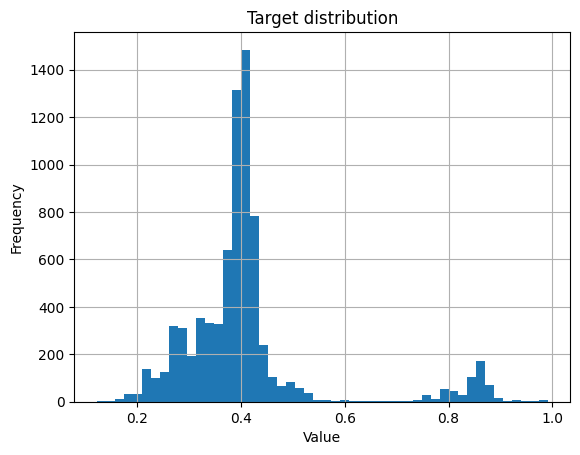

Target variable statistics:
Mean: 0.4083971804178682
Std: 0.1369963149028751


In [3]:
# check target variable distribution
# target variable is COL_134
import matplotlib.pyplot as plt
df_final["COL_134"].hist(bins=50)
plt.title("Target distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

print(f"Target variable statistics:")
print(f"Mean: {df_final['COL_134'].mean()}")
print(f"Std: {df_final['COL_134'].std()}")

 Target distibution looks slightly bimodal, this might indicate some possible outliers on the right side. Multimodality has a significant effect on several statistical models as it skews statistical indicators. 

# Fit regression model to data

There are several options for models. In this case we use readymade sklearn library models. For linear model ridge regression is used and for nonlinear model neural network regression is used.

The modelling process is done as follows: first the data is split into training, validation and testing groups. The first 2 groups are used for training the model. First selecting the used features and then fine tuning the parameters. The final group is saved for validating the model performance with completely new data for the model. The training step uses sklearn Pipeline feature with k-fold crosvalidation for this split. 

The model requires feature selection. In this case there are total 50 features. The guaranteed optimal feature combination can be selected by training a model for every feature combination, however this is impractical with this many feature. F score-based feature selection is used with $\textbf{f regression}$ to evaluate features. It ranks features by correlation with the target variable.

Model hyperparameter tuning uses Pipeline structure with sampling over with grid search to find best performing parameter combination. 

The best model for use is selected as the lowest MSE error model parameter out of the tested models and hyperparameter combinations.
( the current code takes around 3 minutes to run with 16core 4ghz cpu multithreaded. Consider testing less parameters if on a slower pc. Pipeline multithreads the training to all cores automatically with the njobs=-1)





In [9]:
import sklearn as sk
from sklearn.model_selection import train_test_split

#split data into features and test + train sets

Y = df_final["COL_134"]  # target variable
X = df_final.drop(columns=["COL_134"])  # features

#train test split standard 20% for one shot testing 90% for training and validation
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, random_state=37)

#check dimensions of train and test sets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


#perform feature selection using SelectKbest in a pipeline
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_regression
from sklearn.linear_model import Ridge # ridge regression model
from sklearn.pipeline import Pipeline # pipeline for feature selection and regression
from sklearn.neural_network import MLPRegressor # neural network regression model
from sklearn.preprocessing import StandardScaler #scaling features for regression
from sklearn.impute import SimpleImputer #imputation for missing values
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV # cross validation and grid search
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression # better for MLPRegressor non linear relationships taken into account

#model tuning with gridsearch 
outer_cv = KFold(n_splits=5, shuffle=True, random_state=37)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=37)

# Define candidate models with their hyperparameter grids
# 
candidates = {
    "Ridge": (
        Pipeline([
            ("imputer",  SimpleImputer(strategy="median")), # note this does nothing as na values were dropped in last step but is left here for future use if imputation is needed
            ("scaler",   StandardScaler()),
            ("var_filter", VarianceThreshold(threshold=0.01)),  # filters for low variance features 
            ("selector", SelectKBest(f_regression)),
            ("model",    Ridge())
        ]),
        {"selector__k": [10, 20, 30], "model__alpha": [ 0.1, 1, 10]}
        ),
    "MLPRegressor": (
        Pipeline([
            ("imputer",  SimpleImputer(strategy="median")),
            ("scaler",   StandardScaler()),
            ("var_filter", VarianceThreshold(threshold=0.01)),  # filters for low variance features
            ("selector", SelectKBest(mutual_info_regression)),  # better for MLP,
            ("model",    MLPRegressor(max_iter=5000,random_state=37))
        ]),
        {"selector__k": [10, 20, 30], # how many features to select (length reduced after indentifying 30 as best for faster training)
        "model__hidden_layer_sizes":  [(100,), (100, 100), (100, 50, 25),(300, 150, 75),(256, 128, 64,32,8)],# number of neurons in each layer, more layers and neurons can capture more complex relationships but also increase risk of overfitting and training time
        "model__alpha": [ 0.001, 0.01], # reqularization parameter
        "model__activation": ["relu"], # activation function between layers 
        "model__solver": ["adam"], # optimization solver adjusts step size dynamically 
        "model__learning_rate": ["adaptive"]} # adaptive changes parameter learning rate based on training progress
        ) # model architecture is scaled up to 100 neurons in one layer and 3 layers with decreasing
         # number of neurons. The pipeline fits the number of features to this automatically
         #this means some combinations might not perfom well but these should not be selected
         # for more complex feature spesicic architectures the layer sizes could be defined as a function of features

}

# Run nested CV for each candidate
results = {}
for name, (pipe, param_grid) in candidates.items():
    inner_search = GridSearchCV(pipe, param_grid, cv=inner_cv,
                                scoring="neg_root_mean_squared_error", n_jobs=-1)
    outer_scores = cross_val_score(inner_search, X_train, y_train,
                                   cv=outer_cv, scoring="neg_root_mean_squared_error",
                                   n_jobs=-1)
    results[name] = -outer_scores  # flip sign: lower RMSE is better
    print(f"{name}: RMSE = {-outer_scores.mean():.4f} ± {outer_scores.std():.4f}")


# save best model paramaters and refit on full training set
best_name = min(results, key=lambda k: results[k].mean())
best_pipe, best_params = candidates[best_name]

# Refit with inner CV on full training set
final_model = GridSearchCV(best_pipe, best_params, cv=inner_cv,
                           scoring="neg_root_mean_squared_error", n_jobs=-1)
final_model.fit(X_train, y_train)

print(f"\nBest model: {best_name}")
print(f"Best params: {final_model.best_params_}")

#Test model on test set
y_pred = final_model.predict(X_test)
print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred):.4f}")

cv_rmse = results[best_name].mean()
test_rmse = root_mean_squared_error(y_test, y_pred)
gap = abs(test_rmse - cv_rmse)
print(f"CV RMSE: {cv_rmse:.4f}  Test RMSE: {test_rmse:.4f}  Gap: {gap:.4f}")
#import pickle
# Save the best model to a file
#with open("best_model.pkl", "wb") as f:
#    pickle.dump(final_model, f)

X_train shape: (6915, 50)
y_train shape: (6915,)
Ridge: RMSE = 0.1215 ± 0.0033
MLPRegressor: RMSE = 0.1104 ± 0.0025

Best model: MLPRegressor
Best params: {'model__activation': 'relu', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (256, 128, 64, 32, 8), 'model__learning_rate': 'adaptive', 'model__solver': 'adam', 'selector__k': 10}
Test RMSE: 0.1106
Test R²:   0.3880
CV RMSE: 0.1104  Test RMSE: 0.1106  Gap: 0.0002


In [10]:
# model summary

# model details are saved in the best model object final_model which is a GridSearchCV object containing the best fitted pipeline and its parameters.
# Get the selector step from the best fitted pipeline
selector = final_model.best_estimator_.named_steps["selector"]
feature_mask = selector.get_support()
selected_features = X_train.columns[selector.get_support(indices=True)].tolist()

print(f"Selected {len(selected_features)} features:")
print(selected_features)


# Get the var_filter step to know which features passed
var_filter = final_model.best_estimator_.named_steps["var_filter"]
var_filter_mask = var_filter.get_support()
filtered_features = X_train.columns[var_filter_mask]

# Now create the dataframe with matching lengths
feature_scores = pd.DataFrame({
    "feature": filtered_features,
    "f_score/m_info_score": selector.scores_,
    "selected": feature_mask
}).sort_values("f_score/m_info_score", ascending=False)

print(feature_scores[feature_scores["selected"]])

Selected 10 features:
['COL_002', 'COL_004', 'COL_008', 'COL_009', 'COL_033', 'COL_059', 'COL_082', 'COL_097', 'COL_098', 'COL_099']
    feature  f_score/m_info_score  selected
46  COL_100              1.260932      True
6   COL_008              0.821383      True
3   COL_004              0.799758      True
2   COL_002              0.782104      True
38       ID              0.709443      True
47  COL_101              0.707363      True
7   COL_009              0.500546      True
20  COL_034              0.348745      True
34  COL_069              0.302785      True
45  COL_099              0.269897      True


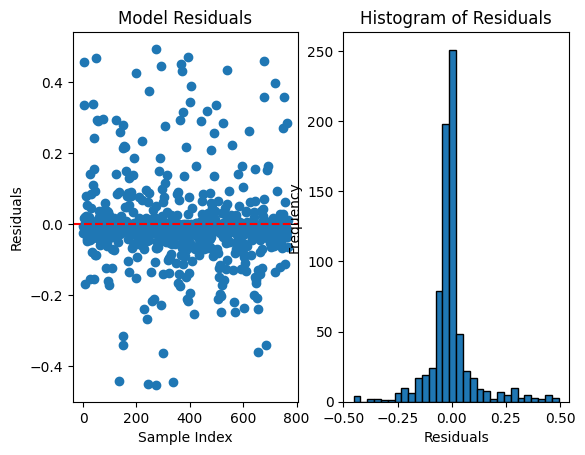

In [11]:
#print(df_final["COL_004"].describe())
import matplotlib.pyplot as plt
# plot model residuals and histogram of residuals to check for normal distribution and homoscedasticity
residuals = y_test - y_pred
plt.subplot(1, 2, 1)
plt.scatter(range(len(residuals)), residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Sample Index")
plt.ylabel("Residuals")
plt.title("Model Residuals")

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

plt.show()


Residuals seem mostly ok. Ideal would be normally distributed in this case there are more large values. These match with the shape of the target distribution. The model accuracy could be better but is sufficient as the focus of the assigment was in the process instead of maximum accuracy.

Text(0.5, 1.0, 'Residual Plot')

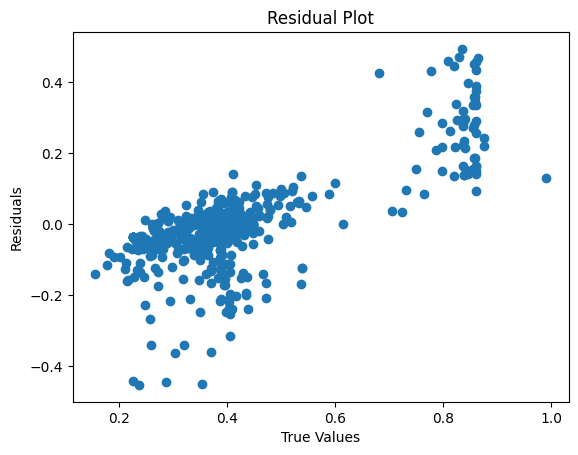

In [13]:
plt.scatter(y_test, residuals)
plt.xlabel("True Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")


# Additional steps

The current model training has identified MLPregressor neural network as a suitable model type. Based on the residuals the main data on left is easier to fit than the second peak on the right in the target variable distribution. Further model fitting could achieve better performance with larger neural network. 

In production use the model would be either saved and used as is or deployed to cloud platform for continuous training. The relative large  number of missing values around 26% of data should be looked at when improving the data collection pipeline.

The target distribution should be looked into if there are potential measuremement errors causing the multimodal distribution. Fitting a model to only one mode of data would lead to a better model perfomance. 

In [16]:
# copy of training for further testing larger neural network
import sklearn as sk
from sklearn.model_selection import train_test_split

# test training on only first mode of data with Y <0.7
df_1mode = df_final[df_final["COL_134"] < 0.7]

#split data into features and test + train sets

Y = df_1mode["COL_134"]  # target variable
X = df_1mode.drop(columns=["COL_134"])  # features

#train test split standard 20% for one shot testing 90% for training and validation
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1, random_state=37)

#check dimensions of train and test sets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


#perform feature selection using SelectKbest in a pipeline
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_regression
from sklearn.linear_model import Ridge # ridge regression model
from sklearn.pipeline import Pipeline # pipeline for feature selection and regression
from sklearn.neural_network import MLPRegressor # neural network regression model
from sklearn.preprocessing import StandardScaler #scaling features for regression
from sklearn.impute import SimpleImputer #imputation for missing values
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV # cross validation and grid search
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.feature_selection import mutual_info_regression # better for MLPRegressor non linear relationships taken into account

#model tuning with gridsearch 
outer_cv2 = KFold(n_splits=5, shuffle=True, random_state=37)
inner_cv2 = KFold(n_splits=3, shuffle=True, random_state=37)

# Define candidate models with their hyperparameter grids
# 
candidates2 = {
    "MLPRegressor": (
        Pipeline([
            ("imputer",  SimpleImputer(strategy="median")),
            ("scaler",   StandardScaler()),
            ("var_filter", VarianceThreshold(threshold=0.01)),  # filters for low variance features
            ("selector", SelectKBest(mutual_info_regression)),  # better for MLP,
            ("model",    MLPRegressor(max_iter=10000,random_state=37))
        ]),
        {"selector__k": [10], # how many features to select (length reduced after indentifying 30 as best for faster training)
        "model__hidden_layer_sizes":  [(256, 128, 64,32,8),(100,100,100,50,50,25,10,5)],# number of neurons in each layer, more layers and neurons can capture more complex relationships but also increase risk of overfitting and training time
        "model__alpha": [ 0.001, 0.01], # reqularization parameter
        "model__activation": ["relu"], # activation function between layers 
        "model__solver": ["adam"], # optimization solver adjusts step size dynamically 
        "model__learning_rate": ["adaptive"]} # adaptive changes parameter learning rate based on training progress
        ) # model architecture is scaled up to 100 neurons in one layer and 3 layers with decreasing
         # number of neurons. The pipeline fits the number of features to this automatically
         #this means some combinations might not perfom well but these should not be selected
         # for more complex feature spesicic architectures the layer sizes could be defined as a function of features

}

# Run nested CV for each candidate
results2 = {}
for name, (pipe, param_grid) in candidates2.items():
    inner_search = GridSearchCV(pipe, param_grid, cv=inner_cv2,
                                scoring="neg_root_mean_squared_error", n_jobs=-1)
    outer_scores = cross_val_score(inner_search, X_train, y_train,
                                   cv=outer_cv2, scoring="neg_root_mean_squared_error",
                                   n_jobs=-1)
    results2[name] = -outer_scores  # flip sign: lower RMSE is better
    print(f"{name}: RMSE = {-outer_scores.mean():.4f} ± {outer_scores.std():.4f}")


# save best model paramaters and refit on full training set
best_name2 = min(results2, key=lambda k: results2[k].mean())
best_pipe2, best_params = candidates2[best_name2]

# Refit with inner CV on full training set
final_model2 = GridSearchCV(best_pipe2, best_params, cv=inner_cv2,
                           scoring="neg_root_mean_squared_error", n_jobs=-1)
final_model2.fit(X_train, y_train)

print(f"\nBest model: {best_name2}")
print(f"Best params: {final_model2.best_params_}")

#Test model on test set
y_pred2 = final_model2.predict(X_test)
print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred2):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred2):.4f}")

cv_rmse2 = results2[best_name2].mean()
test_rmse2 = root_mean_squared_error(y_test, y_pred2)
gap2 = abs(test_rmse2 - cv_rmse2)
print(f"CV RMSE: {cv_rmse2:.4f}  Test RMSE: {test_rmse2:.4f}  Gap: {gap2:.4f}")
#import pickle
# Save the best model to a file
#with open("best_model.pkl", "wb") as f:
#    pickle.dump(final_model, f)

X_train shape: (6410, 50)
y_train shape: (6410,)
MLPRegressor: RMSE = 0.0449 ± 0.0020

Best model: MLPRegressor
Best params: {'model__activation': 'relu', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (256, 128, 64, 32, 8), 'model__learning_rate': 'adaptive', 'model__solver': 'adam', 'selector__k': 10}
Test RMSE: 0.0422
Test R²:   0.5590
CV RMSE: 0.0449  Test RMSE: 0.0422  Gap: 0.0027


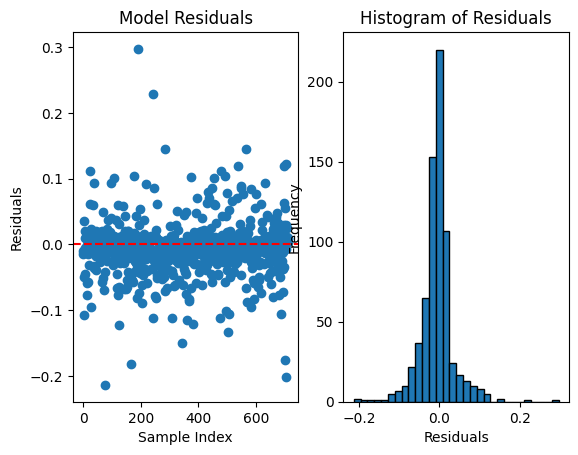

In [17]:
#print(df_final["COL_004"].describe())
import matplotlib.pyplot as plt
# plot model residuals and histogram of residuals to check for normal distribution and homoscedasticity
residuals = y_test - y_pred2
plt.subplot(1, 2, 1)
plt.scatter(range(len(residuals)), residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Sample Index")
plt.ylabel("Residuals")
plt.title("Model Residuals")

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

plt.show()